In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

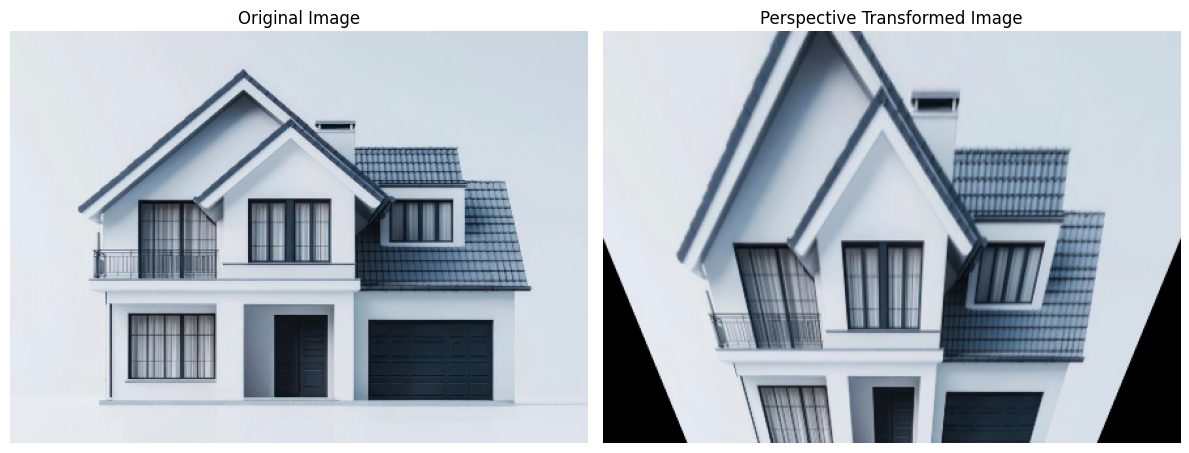

In [5]:
# Read input image
img = cv2.imread("image.png")
if img is None:
  print("Image not found")
  exit()

# Get image dimensions
height, width = img.shape[:2]

# Source points
pts1 = np.float32([
    [50, 50],
    [width - 50, 50],
    [50, height - 50],
    [width - 50, height - 50]
])

# Destination points (where the corners should move)
pts2 = np.float32([
    [0, 0],
    [width, 0],
    [100, height],
    [width - 100, height]
])

# Perspective transformation matrix
matrix = cv2.getPerspectiveTransform(pts1, pts2)

# Apply perspective transformation
result = cv2.warpPerspective(img, matrix, (width, height))

# Convert BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Display images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title("Perspective Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()